In [ ]:
%pip install -q rasterio geopandas torch torchvision numpy scikit-image matplotlib tqdm pyproj rtree

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, glob, math, random, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import rasterio
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling, calculate_default_transform
import geopandas as gpd
from rasterio.features import rasterize
from skimage.util import view_as_windows

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


# Dataset

In [4]:
#@title Inputs
NDVI_PATH = "/content/drive/MyDrive/TFM/dev/dataset/UAV/Orthomosaic.tif" # @param {type:"string"}
UAV_DIR   = "/content/drive/MyDrive/TFM/dev/dataset/UAV/images/raw_images/" # @param {type:"string"}
ROSETTE_SHP = "/content/drive/MyDrive/TFM/dev/dataset/UAV/images/annotated_rosettes/annotated_rosettes.shp" # @param {type:"string"}
OUT_DIR = "/content/drive/MyDrive/TFM/dev/ARC-NCA/NDVI/output" # @param {type:"string"}

In [10]:
import rasterio
with rasterio.open(NDVI_PATH) as src:
    print(src.crs)

EPSG:32721


In [5]:
#@title Utilidades de IO y reproyección (NDVI tiling + muestreo UAV)
def open_raster(path):
    src = rasterio.open(path)
    return src

# Normalización NDVI helper
def normalize01(arr, clip_percentiles=(1,99)):
    # clip then scale 0..1
    lo, hi = np.percentile(arr[~np.isnan(arr)], clip_percentiles)
    a = np.clip(arr, lo, hi)
    a = (a - lo) / (hi - lo + 1e-9)
    return a

# Read a window from single-band ndvi raster and return float32 2D array
def read_ndvi_window(src_ndvi, row_off, col_off, height, width):
    window = Window(col_off, row_off, width, height)
    arr = src_ndvi.read(1, window=window, boundless=True, fill_value=np.nan).astype(np.float32)
    # replace nan with 0 for convenience but we also pass validity mask
    valid = ~np.isnan(arr)
    arr_f = np.nan_to_num(arr, nan=0.0)
    return arr_f, valid.astype(np.uint8)

# Sample UAV RGB to target window (reproject UAV to NDVI window grid)
def sample_uav_to_window(uav_path, dst_transform, dst_crs, height, width):
    """
    Reads a UAV raster (if georef) and reprojects/resamples into a destination grid.
    Returns RGB array shape (3, H, W) normalized 0..1. If UAV not georeferenced or fails, returns None.
    """
    try:
        with rasterio.open(uav_path) as src:
            # prepare dest array
            dst = np.zeros((src.count, height, width), dtype=np.float32)
            dst_affine = dst_transform
            dst_crs_local = dst_crs
            reproject(
                source=rasterio.band(src, list(range(1, src.count+1))),
                destination=dst,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_affine,
                dst_crs=dst_crs_local,
                resampling=Resampling.bilinear,
                num_threads=2
            )
            # If UAV has >3 bands, pick first 3
            if dst.shape[0] >= 3:
                rgb = dst[:3, :, :]
            else:
                # if single band, replicate
                rgb = np.tile(dst[0:1], (3,1,1))
            # normalize to 0..1
            # if values >1 (e.g. 0-255), scale
            if rgb.max() > 1.0:
                rgb = rgb / 255.0
            rgb = np.clip(rgb, 0.0, 1.0).astype(np.float32)
            return rgb
    except Exception as e:
        # fallback: UAV not georeferenced or reprojection failed
        # print(e)
        return None

# Build tile metadata from NDVI raster: yields windows and transforms
def create_tiles_from_ndvi(ndvi_path, patch_size=128, stride=64, nodata_value=np.nan):
    src = rasterio.open(ndvi_path)
    H, W = src.height, src.width
    tiles = []
    for row in range(0, H - patch_size + 1, stride):
        for col in range(0, W - patch_size + 1, stride):
            win = Window(col, row, patch_size, patch_size)
            transform = rasterio.windows.transform(win, src.transform)
            tiles.append({
                "row_off": row,
                "col_off": col,
                "height": patch_size,
                "width": patch_size,
                "transform": transform,
                "crs": src.crs,
            })
    src.close()
    return tiles


In [6]:
#@title Rasterize rosette shapefile to NDVI grid
def rosette_raster_from_shp(shp_path, ndvi_path):
    if not os.path.exists(shp_path):
        print("No shapefile path, returning None")
        return None
    gdf = gpd.read_file(shp_path)
    with rasterio.open(ndvi_path) as src:
        out_shape = (src.height, src.width)
        transform = src.transform
        raster = rasterize(
            [(geom, 1) for geom in gdf.geometry],
            out_shape=out_shape,
            transform=transform,
            fill=0,
            all_touched=True,
            dtype=np.uint8
        )
    return raster

# precompute rosette raster if shp provided
if os.path.exists(ROSETTE_SHP):
    print("Rasterizing rosette shapefile (may take a while)...")
    rosette_raster = rosette_raster_from_shp(ROSETTE_SHP, NDVI_PATH)
    np.save(os.path.join(OUT_DIR, "rosette_raster.npy"), rosette_raster)
    print("Saved rosette raster.")
else:
    rosette_raster = None
    print("No rosette shapefile found.")


Rasterizing rosette shapefile (may take a while)...


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


Saved rosette raster.


In [7]:
#@title Georeference UAV Images (EPSG:32721)
import rasterio
from rasterio.transform import from_origin
from pathlib import Path
from PIL import Image
import numpy as np

def georeference_uav_images(uav_folder, reference_tif, output_folder, grid_size=800):
    """
    Assign EPSG:32721 CRS to UAV JPEG images based on reference TIF extent.

    Parameters
    ----------
    uav_folder : str or Path
        Directory containing UAV JPEG images.
    reference_tif : str or Path
        Path to the georeferenced large TIF (reference field image).
    output_folder : str or Path
        Directory where georeferenced UAV GeoTIFFs will be saved.
    grid_size : int
        Size (in pixels) of each UAV image footprint relative to TIF extent.
    """
    uav_folder = Path(uav_folder)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    with rasterio.open(reference_tif) as ref:
        crs = ref.crs
        transform = ref.transform
        width, height = ref.width, ref.height
        xres, yres = ref.res

    jpeg_files = sorted(list(uav_folder.glob("*.JPG")))
    if not jpeg_files:
        print(f"⚠️ No UAV JPEG files found in {uav_folder}")
        return

    print(f"Found {len(jpeg_files)} UAV images — assigning CRS: {crs}")

    for idx, jpeg_path in enumerate(jpeg_files):
        img = np.array(Image.open(jpeg_path).convert("RGB"))
        h, w, _ = img.shape

        # Compute approximate UAV position in reference extent (grid-based layout)
        col = (idx * grid_size) % (width - grid_size)
        row = ((idx * grid_size) // (width - grid_size)) * grid_size

        # Compute affine transform for UAV patch
        x0, y0 = transform * (col, row)
        new_transform = from_origin(x0, y0, xres, yres)

        out_path = output_folder / f"{jpeg_path.stem}_geo.tif"
        with rasterio.open(
            out_path,
            "w",
            driver="GTiff",
            height=h,
            width=w,
            count=3,
            dtype=img.dtype,
            crs=crs,
            transform=new_transform,
        ) as dst:
            for i in range(3):
                dst.write(img[:, :, i], i + 1)

    print(f"✅ UAV images georeferenced and saved to: {output_folder}")


# Integration point within ARC_NCA-NDVI workflow
# This should be executed before dataset creation and visualization steps.
georeference_uav_images(
    uav_folder=UAV_DIR,
    reference_tif=NDVI_PATH,
    output_folder="/content/drive/MyDrive/TFM/dev/dataset/UAV/images/UAV_georef/",
    grid_size=800
)


Found 832 UAV images — assigning CRS: EPSG:32721


KeyboardInterrupt: 

In [8]:
# @title Dataset class: builds patches combining NDVI masked + sampled UAV RGB

class NDVI_UAV_PatchDataset(Dataset):
    def __init__(self, ndvi_path, uav_dir, tiles_meta, rosette_raster=None,
                 patch_size=128, mask_prob=0.25, transform=None, fallback_rgb=(0.5,0.5,0.5)):
        """
        ndvi_path: path to NDVI tif
        uav_dir: directory with UAV ortho rasters (georef). If empty, fallback used.
        tiles_meta: list of tile metadata dicts from create_tiles_from_ndvi
        rosette_raster: full raster (H,W) with 0/1 rosette mask (optional)
        mask_prob: probability of masking pixels (cloud sim)
        fallback_rgb: value to fill if no UAV available for that tile (tuple of 3 floats)
        """
        # if not Path("data/UAV_georef").exists():
        #   georeference_uav_images(
        #       uav_folder=UAV_DIR,
        #       reference_tif="data/large_field_image.tif",
        #       output_folder="data/UAV_georef/",
        #       grid_size=800
        #   )
        self.uav_list = sorted(glob.glob(os.path.join(uav_dir, "*"))) if uav_dir and os.path.exists(uav_dir) else []
        self.ndvi_path = ndvi_path
        self.uav_dir = uav_dir
        self.tiles = tiles_meta
        self.patch_size = patch_size
        self.mask_prob = mask_prob
        self.transform = transform
        self.fallback_rgb = np.array(fallback_rgb, dtype=np.float32)
        self.rosette_raster = rosette_raster
        self.uav_list = sorted(glob.glob(os.path.join(uav_dir, "*"))) if uav_dir and os.path.exists(uav_dir) else []

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        t = self.tiles[idx]
        with rasterio.open(self.ndvi_path) as src:
            ndvi_patch = src.read(1, window=Window(t["col_off"], t["row_off"], t["width"], t["height"]), boundless=True, fill_value=np.nan).astype(np.float32)
            # validity mask
            valid_mask = (~np.isnan(ndvi_patch)).astype(np.uint8)
            ndvi_patch = np.nan_to_num(ndvi_patch, nan=0.0)
            ndvi_patch = normalize01(ndvi_patch)
            # simulate partial observation mask (clouds):
            obs_mask = (np.random.rand(*ndvi_patch.shape) > self.mask_prob).astype(np.float32)
            ndvi_masked = ndvi_patch * obs_mask

        # sample UAV: try each UAV file until one produces a non-None sample
        rgb = None
        for uav_path in self.uav_list:
            rgb = sample_uav_to_window(uav_path, t["transform"], t["crs"], t["height"], t["width"])
            if rgb is not None:
                break
        if rgb is None:
            # fallback constant RGB or small random noise around fallback
            rgb = np.tile(self.fallback_rgb.reshape(3,1,1), (1, self.patch_size, self.patch_size))
            rgb = rgb + (np.random.randn(*rgb.shape) * 0.02).astype(np.float32)
            rgb = np.clip(rgb, 0.0, 1.0)

        # rosette patch (if available)
        rosette_patch = None
        if self.rosette_raster is not None:
            rosette_patch = self.rosette_raster[t["row_off"]:t["row_off"]+t["height"], t["col_off"]:t["col_off"]+t["width"]]
            if rosette_patch.shape != (self.patch_size, self.patch_size):
                # pad/crop if needed
                rp = np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)
                h0, w0 = rosette_patch.shape
                rp[:h0, :w0] = rosette_patch
                rosette_patch = rp
        else:
            rosette_patch = np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)

        # Build input tensor: [R,G,B, NDVI_masked, obs_mask, rosette_mask]  --> we will choose subset for model
        # We'll use input_channels = 4: [R,G,B, NDVI_masked]; keep obs_mask and rosette as aux
        input_array = np.concatenate([rgb, ndvi_masked[None,...]], axis=0).astype(np.float32)  # shape (4,H,W)
        sample = {
            "input": input_array,
            "target": ndvi_patch.astype(np.float32)[None, ...],
            "obs_mask": obs_mask.astype(np.float32)[None, ...],
            "rosette": rosette_patch.astype(np.float32)[None, ...]
        }
        # optional transforms (augmentations)
        if self.transform:
            sample = self.transform(sample)
        return {k: torch.from_numpy(v) for k,v in sample.items()}


In [9]:
# @title Create tiles metadata and dataset instance
PATCH_SIZE = 128 # @param {type:"number"}
STRIDE = 64 # @param {type:"number"}
tiles = create_tiles_from_ndvi(NDVI_PATH, patch_size=PATCH_SIZE, stride=STRIDE)
print("Total tiles:", len(tiles))

# load precomputed rosette raster if saved
if os.path.exists(os.path.join(OUT_DIR, "rosette_raster.npy")):
    rosette_raster = np.load(os.path.join(OUT_DIR, "rosette_raster.npy"))
else:
    rosette_raster = rosette_raster  # from earlier cell, might be None

dataset = NDVI_UAV_PatchDataset(
    ndvi_path=NDVI_PATH,
    uav_dir="/content/drive/MyDrive/TFM/dev/dataset/UAV/images/UAV_georef/",
    tiles_meta=tiles,
    rosette_raster=rosette_raster,
    patch_size=PATCH_SIZE,
    mask_prob=0.25,
    fallback_rgb=(0.45, 0.56, 0.32)  # adjust color if you want
)
print("Dataset length:", len(dataset))

Total tiles: 328208
Dataset length: 328208


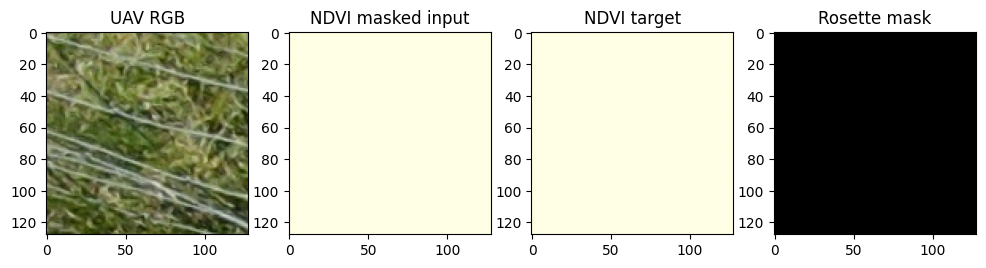

In [27]:
# @title Test sample visualization
sample = dataset[0]
inp = sample["input"].numpy()
tgt = sample["target"].numpy().squeeze()
obs_mask = sample["obs_mask"].numpy().squeeze()
rosette = sample["rosette"].numpy().squeeze()

plt.figure(figsize=(12,4))
plt.subplot(1,4,1); plt.imshow(np.transpose(inp[:3], (1,2,0))); plt.title("UAV RGB")
plt.subplot(1,4,2); plt.imshow(inp[3], cmap='YlGn'); plt.title("NDVI masked input")
plt.subplot(1,4,3); plt.imshow(tgt, cmap='YlGn'); plt.title("NDVI target")
plt.subplot(1,4,4); plt.imshow(rosette, cmap='gray'); plt.title("Rosette mask")
plt.show()


# Diseño del modelo AI

In [28]:
#@title Utilities
def gaussian_blur_kernel(channels: int, kernel_size: int = 3, sigma: float = 1.0, device=None):
    # small gaussian kernel for smoothing (used optionally)
    ax = torch.arange(-kernel_size // 2 + 1., kernel_size // 2 + 1., device=device)
    xx = ax.unsqueeze(0)
    yy = ax.unsqueeze(1)
    kernel = torch.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel = kernel / kernel.sum()
    kernel = kernel.view(1, 1, kernel_size, kernel_size).repeat(channels, 1, 1, 1)
    return kernel

def total_variation_loss(x):
    # x: (B, C, H, W) or single channel (we'll apply on predicted NDVI (B,1,H,W))
    dh = torch.mean(torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]))
    dw = torch.mean(torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]))
    return dh + dw

In [10]:
#@title Local Attention module (ARC-like)
#@markdown - compute local keys/queries on 3x3 neighborhood using unfold
class LocalAttention3x3(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.q = nn.Conv2d(channels, channels, 1)
        self.k = nn.Conv2d(channels, channels, 1)
        self.v = nn.Conv2d(channels, channels, 1)
        self.out = nn.Conv2d(channels, channels, 1)
        self.scale = 1.0 / math.sqrt(max(1, channels))

    def forward(self, x):
        # x: (B,C,H,W)
        B,C,H,W = x.shape
        q = self.q(x)    # B,C,H,W
        k = self.k(x)
        v = self.v(x)
        # unfold neighbors 3x3
        k_p = F.unfold(k, kernel_size=3, padding=1).view(B, C, 9, H, W)
        v_p = F.unfold(v, kernel_size=3, padding=1).view(B, C, 9, H, W)
        q = q.unsqueeze(2)  # B,C,1,H,W
        attn = (q * k_p).sum(dim=1) * self.scale  # B,9,H,W
        attn = F.softmax(attn.view(B,9,H*W), dim=1).view(B,9,H,W)
        attn = attn.unsqueeze(1)  # B,1,9,H,W
        out = (attn * v_p).sum(dim=2)  # B,C,H,W
        out = self.out(out)
        return out

In [ ]:
#@title NCA Update block (cell)
class NCACell(nn.Module):
  def __init__(self, channels: int, hidden: int=128, step_gain: float = 1.0):
    """
    channels: number of channels in input (state channels)
    hidden: hidden dim in the MLP applied after perception
    """
    super().__init__()
    self.perception = nn.Sequential(
        nn.Conv2d(channels, channels, kernel_size=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(channels, channels, kernel_size=1),
        nn.ReLU(),
    )

    # ARC-like local attention
    self.local_attention = LocalAttention3x3(hidden)
    # Final update projection
    self.delta_proj = nn.Conv2d(hidden, channels, kernel_size=1)
    # gating (learned)
    self.step_gain = step_gain
    self.gate = nn.Conv2d(hidden, channels, kernel_size=1)

  def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    x: state tensor (B, C, H, W)
    returns: delta (B, C, H, W) and gate (B, C, H, W) in (0,1)
    """
    p = self.perception(x) # (B, C, H, W)
    a = self.local_attention(p) # (B, C, H, W)
    merge = p + p_att
    delta = self.deltra_proj(merged)
    gate = torch.sigmoid(self.gate(merged))
    return delta * self.step_gain, gate

In [ ]:
#@title ARC-NCA
class ARC_NCA(nn.Module):
  def __init__(
      self,
      input_channels: int,
      state_channels: int = 32,
      target_channels: int = 1,
      hidden: int = 128,
      device: Optional[torch.device] = None
  ):
    """
    input_channels: number of fixed input channels concatenated to state (e.g., RGB + obs_mask)
    state_channels: number of latent state channels (including channels reserved for fixed inputs)
    target_channels: number of output channels (e.g., NDVI -> 1)
    """
    super().__init__()
    self.state_channels = state_channels
    self.input_channels = input_channels
    self.target_channels = target_channels
    self.device = device or torch.device("cpu")

    # An encoder to inject observations into some reserved channels of the state
    self.obs_encoder = nn.Conv2d(input_channels, state_channels, kernel_size=1)

    # NCA update cell
    self.cell = NCACell(state_channels, hidden=hidden)

    # readout head to extract target from state
    self.readout = nn.Sequential(
        nn.Conv2d(state_channels, hidden // 2, kernel_size=1),
        nn.ReLU(),
        nn.Conv2d(hidden // 2, target_channels, kernel_size=1)
    )

    # initial alive channel index (we wull use one state channel for alive)
    self.alive_channel = 0

  def init_state(self, batch_size: int, height: int, width: int):
    s = torch.zeros(batch, self.state_channels, height, width, device=self.device)
    s += (torch.randn_like(s) * 1e-3)
    return s

  def inject_observation(self,state,obs):
    """
    obs: (B, input_channels, H, W) - fixed inputs (bands + obs_mask)
    We'll encode obs into the state by adding a projection
    """
    encoded = self.obs_encoder(obs)
    # add encoded obs to state (residual injection)
    return state + encoded

  def forward(self, initial_state, obs, n_steps: int = 16, alive_mask: Optional[torch.Tensor] = None):
    """
    initial_state: (B, S, H, W)
    obs: (B, input_channels, H, W)
    alive_mask: optional binary mask (B,1,H,W) indicating valid pixels to update
    returns: list of readouts at last step (and optionally intermediate steps)
    """
    state = self.inject_observation(initial_state, obs)

    if alive_mask is None:
      alive_mask = torch.ones(s.size(0),1,s.size(2),s.size(3), device=s.device)

    readouts = []
    for step in range(n_steps):
      delta, gate = self.cell(s)

      # applying gating and alive mark: only update where alive_mask > 0
      # gate in (0,1) per channel; alive_mask broadcast across channels
      s = s + delta * gate * alive_mask
      # normalization to avoid explosion
      s = torch.tanh(s) # keeps the state bounded - stability
      # readout
      out = self.readout(s)
      readouts.append(out)
      print(f"step {step}: out min/max {out.min().item():.4f}/{out.max().item():.4f}")
    return readouts # list length n_steps, each (B, target_channels, H, W)

In [11]:
# @title ARC-NCA model (multimodal)
# @markdown Model consumes input_channels (here 4: R,G,B,NDVI_masked)

# @markdown Also receives obs_mask and rosette mask as conditioning channels (injected each step)
class ARC_NCA_MultiModal(nn.Module):
    def __init__(self, input_channels=4, state_channels=32, hidden=128, target_channels=1, step_gain=1.0):
        super().__init__()
        self.input_channels = input_channels
        self.state_channels = state_channels
        self.target_channels = target_channels
        self.step_gain = step_gain

        # encoder: inject input into initial state
        self.obs_encoder = nn.Conv2d(input_channels, state_channels, kernel_size=1)

        # extra conditioning projector for obs_mask and rosette (1+1 channels)
        self.cond_proj = nn.Conv2d(2, state_channels, kernel_size=1)  # obs_mask + rosette

        # perception and local attention
        self.perception = nn.Conv2d(state_channels, hidden, kernel_size=3, padding=1)
        self.local_attn = LocalAttention3x3(hidden)

        # update MLP
        self.update_mlp = nn.Sequential(
            nn.Conv2d(hidden, hidden, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(hidden, state_channels, kernel_size=1)
        )
        # gate for updates
        self.gate = nn.Conv2d(hidden, state_channels, kernel_size=1)

        # readout head -> NDVI
        self.readout = nn.Sequential(
            nn.Conv2d(state_channels, hidden//2, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(hidden//2, target_channels, kernel_size=1)
        )

    def init_state(self, batch, H, W, device):
        # start from zeros + small noise
        s = torch.randn(batch, self.state_channels, H, W, device=device) * 1e-3
        return s

    def inject_obs(self, state, obs):
        # obs: B, input_channels, H, W
        enc = self.obs_encoder(obs)
        return state + enc

    def forward(self, initial_state, obs, obs_mask=None, rosette=None, n_steps=24, debug=False):
        """
        initial_state: B,S,H,W
        obs: B, input_ch, H, W
        obs_mask: B,1,H,W
        rosette: B,1,H,W
        """
        s = initial_state
        s = self.inject_obs(s, obs)
        if obs_mask is None:
            obs_mask = torch.ones(s.size(0),1,s.size(2),s.size(3), device=s.device)
        if rosette is None:
            rosette = torch.zeros_like(obs_mask)

        cond = torch.cat([obs_mask, rosette], dim=1)  # B,2,H,W
        cond_encoded = self.cond_proj(cond)
        for i in range(n_steps):
            x = s + cond_encoded  # conditioning injected every step
            p = F.relu(self.perception(x))
            p_att = self.local_attn(p)
            merged = p + p_att
            delta = self.update_mlp(merged) * self.step_gain
            gate = torch.sigmoid(self.gate(merged))
            s = s + delta * gate
            # optional stabilize
            s = torch.tanh(s)
            if debug and (i%8==0):
                print(f"step {i}: mean state {s.mean().item():.6f}")
        out = self.readout(s)
        return out

# Training

In [12]:
#@title Loss function: masked self-supervised + smoothness + optional rosette-weighted
def masked_loss(pred, target, obs_mask, rosette=None, alpha_hidden=0.5, tv_weight=0.01):
    """
    pred, target: (B,1,H,W)
    obs_mask: (B,1,H,W) - 1 = observed (visible), 0 = hidden
    alpha_hidden: weight for loss on hidden pixels (we usually care more about hidden rec)
    """
    visible_mask = obs_mask.bool()
    hidden_mask = (~visible_mask)
    # ensure some valid denominator
    denom_vis = visible_mask.sum().float().clamp_min(1.0)
    denom_hid = hidden_mask.sum().float().clamp_min(1.0)

    loss_vis = ((pred - target)**2)[visible_mask].sum() / denom_vis
    loss_hid = ((pred - target)**2)[hidden_mask].sum() / denom_hid

    # total variation (smoothness) on full pred
    tv = torch.mean(torch.abs(pred[:,:,1:,:] - pred[:,:,:-1,:])) + torch.mean(torch.abs(pred[:,:,:,1:] - pred[:,:,:,:-1]))

    loss = loss_vis + alpha_hidden * loss_hid + tv_weight * tv

    # optional rosette weighted emphasis
    if rosette is not None:
        # give more weight inside rosettes for hidden pixels
        rosette_mask = (rosette > 0.5)
        if rosette_mask.sum() > 0:
            rosette_hid = hidden_mask & rosette_mask
            denom_rhid = rosette_hid.sum().float().clamp_min(1.0)
            extra = ((pred - target)**2)[rosette_hid].sum() / denom_rhid
            loss = loss + 0.5 * extra
    return loss


In [ ]:
#@title Training loop
import time

BATCH_SIZE = 4 # @param {type:"number"}
EPOCHS = 20 # @param {type:"number"}
LR = 1e-3 # @param {type:"number"}
N_STEPS = 24 # @param {type:"number"} # NCA iterations

# Add timestamp to the model save path
timestamp = time.strftime("%Y%m%d-%H%M%S")
MODEL_SAVE = os.path.join(OUT_DIR, f"arc_nca_uav_ndvi_{timestamp}.pth")

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
model = ARC_NCA_MultiModal(input_channels=4, state_channels=32, hidden=128, target_channels=1).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = torch.cuda.amp.GradScaler() if DEVICE.startswith("cuda") else None

best_loss = float("inf")
for epoch in range(EPOCHS):
    model.train()
    running = []
    pbar = tqdm(dataloader)
    for batch in pbar:
        inp = batch["input"].to(DEVICE)           # B,4,H,W  (R,G,B, NDVI_masked)
        tgt = batch["target"].to(DEVICE)          # B,1,H,W (NDVI full)
        obs_mask = batch["obs_mask"].to(DEVICE)   # B,1,H,W (1=observed)
        rosette = batch["rosette"].to(DEVICE)     # B,1,H,W

        B, C, H, W = inp.shape
        state0 = model.init_state(B, H, W, device=DEVICE)

        optimizer.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                pred = model(state0, inp, obs_mask=obs_mask, rosette=rosette, n_steps=N_STEPS)
                loss = masked_loss(pred, tgt, obs_mask, rosette=rosette)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(state0, inp, obs_mask=obs_mask, rosette=rosette, n_steps=N_STEPS)
            loss = masked_loss(pred, tgt, obs_mask, rosette=rosette)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        running.append(loss.item())
        pbar.set_description(f"ep{epoch+1} loss:{np.mean(running):.4f}")

    epoch_loss = np.mean(running)
    print(f"Epoch {epoch+1}/{EPOCHS} avg_loss: {epoch_loss:.4f}")

    # save best
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save({"epoch": epoch, "model_state": model.state_dict(), "optimizer": optimizer.state_dict()}, MODEL_SAVE)
        print("Saved best model.")

  0%|          | 0/82052 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
#@title Visualization
# Load best model
ck = torch.load(MODEL_SAVE, map_location=DEVICE)
model.load_state_dict(ck["model_state"])
model.eval()

# Pick a few sample indices and show
def visualize_sample(idx):
    sample = dataset[idx]
    inp = sample["input"].unsqueeze(0).to(DEVICE)     # 1,4,H,W
    tgt = sample["target"].squeeze(0).numpy()
    obs_mask = sample["obs_mask"].unsqueeze(0).to(DEVICE)
    rosette = sample["rosette"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        s0 = model.init_state(1, inp.shape[2], inp.shape[3], device=DEVICE)
        pred = model(s0, inp, obs_mask=obs_mask, rosette=rosette, n_steps=N_STEPS)
    pred_np = pred.squeeze(0).squeeze(0).cpu().numpy()
    inp_ndvi = inp.squeeze(0)[3].cpu().numpy()  # masked NDVI input
    rgb = np.transpose(inp.squeeze(0)[:3].cpu().numpy(), (1,2,0))

    fig, axs = plt.subplots(1,4, figsize=(16,4))
    axs[0].imshow(rgb); axs[0].set_title("UAV RGB")
    axs[1].imshow(inp_ndvi, cmap='YlGn'); axs[1].set_title("NDVI masked input")
    axs[2].imshow(pred_np, cmap='YlGn'); axs[2].set_title("Predicted NDVI")
    axs[3].imshow(tgt, cmap='YlGn'); axs[3].set_title("Ground truth NDVI")
    plt.show()

# visualize 3 random samples
for idx in [0, 5, 10]:
    visualize_sample(idx)


In [ ]:
#@title Reconstruction of a big tale (inference tiling)
# === 11) Cómo usar el modelo para reconstruir un tile grande (inferencia tiling) ==
def reconstruct_full_ndvi(model, ndvi_path, uav_dir, out_path, patch_size=PATCH_SIZE, stride=STRIDE, n_steps=N_STEPS):
    model.eval()
    tiles_meta = create_tiles_from_ndvi(ndvi_path, patch_size=patch_size, stride=stride)
    # create accumulators for reconstruction and counts
    with rasterio.open(ndvi_path) as src:
        H, W = src.height, src.width
        meta = src.meta.copy()
    recon = np.zeros((H, W), dtype=np.float32)
    counts = np.zeros((H, W), dtype=np.float32)

    for i,t in enumerate(tqdm(tiles_meta)):
        # read target window (just to get obs mask and reference transform)
        ndvi_patch, valid = read_ndvi_window(rasterio.open(ndvi_path), t["row_off"], t["col_off"], t["height"], t["width"])
        ndvi_patch = normalize01(ndvi_patch)
        obs_mask = (np.random.rand(*ndvi_patch.shape) > 0.25).astype(np.float32)
        ndvi_masked = ndvi_patch * obs_mask
        # sample UAV
        rgb = None
        for uav_path in sorted(glob.glob(os.path.join(uav_dir,"*"))):
            rgb = sample_uav_to_window(uav_path, t["transform"], t["crs"], t["height"], t["width"])
            if rgb is not None: break
        if rgb is None:
            rgb = np.tile(np.array((0.45, 0.56, 0.32)).reshape(3,1,1),(1,patch_size,patch_size))
        inp = np.concatenate([rgb, ndvi_masked[None,...]], axis=0)[None,...]  # 1,4,H,W
        inp_t = torch.from_numpy(inp).to(DEVICE).float()
        obs_mask_t = torch.from_numpy(obs_mask[None,...]).to(DEVICE).float()
        # rosette optional:
        rosette_patch = np.zeros((1,1,patch_size,patch_size), dtype=np.float32)
        with torch.no_grad():
            s0 = model.init_state(1, patch_size, patch_size, device=DEVICE)
            pred = model(s0, inp_t, obs_mask=obs_mask_t, rosette=torch.from_numpy(rosette_patch).to(DEVICE), n_steps=n_steps)
        pred_np = pred.squeeze(0).squeeze(0).cpu().numpy()
        r0 = t["row_off"]; c0 = t["col_off"]
        recon[r0:r0+patch_size, c0:c0+patch_size] += pred_np
        counts[r0:r0+patch_size, c0:c0+patch_size] += 1.0

    # normalize by counts (avoid division by zero)
    counts[counts==0] = 1.0
    recon = recon / counts
    # save GeoTIFF
    meta.update(counts=1, dtype=rasterio.float32)
    with rasterio.open(out_path, 'w', driver='GTiff', height=recon.shape[0], width=recon.shape[1], count=1, dtype=rasterio.float32, crs=meta['crs'], transform=meta['transform']) as dst:
        dst.write(recon.astype(np.float32), 1)
    print("Saved reconstructed NDVI to", out_path)

# Uso (descomenta para ejecutar)
# reconstruct_full_ndvi(model, NDVI_PATH, UAV_DIR, os.path.join(OUT_DIR, "reconstructed_ndvi.tif"))
